# NEU-DET Class Visualizer
Shows sample images with bounding boxes for all 6 defect classes so you can pick 3 visually distinct ones.

In [1]:
import xml.etree.ElementTree as ET
from pathlib import Path
import random

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
NEU_DET = Path("../NEU-DET/train")
IMAGES_DIR = NEU_DET / "images"
ANNOT_DIR = NEU_DET / "annotations"

CLASSES = ["crazing", "inclusion", "patches", "pitted_surface", "rolled-in_scale", "scratches"]
SAMPLES_PER_CLASS = 6  # images shown per class
SEED = 42

In [3]:
def load_boxes(xml_path):
    """Return list of (label, xmin, ymin, xmax, ymax) from a Pascal VOC XML."""
    root = ET.parse(xml_path).getroot()
    boxes = []
    for obj in root.findall("object"):
        label = obj.find("name").text
        bb = obj.find("bndbox")
        boxes.append((
            label,
            int(bb.find("xmin").text),
            int(bb.find("ymin").text),
            int(bb.find("xmax").text),
            int(bb.find("ymax").text),
        ))
    return boxes


def show_class_grid(cls_name, n=SAMPLES_PER_CLASS, seed=SEED):
    img_dir = IMAGES_DIR / cls_name
    images = sorted(img_dir.glob("*.jpg"))
    rng = random.Random(seed)
    sample = rng.sample(images, min(n, len(images)))

    cols = n
    fig, axes = plt.subplots(1, cols, figsize=(cols * 2.5, 3))
    fig.suptitle(cls_name.replace("_", " ").replace("-", " ").title(), fontsize=14, fontweight="bold", y=1.02)

    for ax, img_path in zip(axes, sample):
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img, cmap="gray")

        xml_path = ANNOT_DIR / (img_path.stem + ".xml")
        if xml_path.exists():
            for label, xmin, ymin, xmax, ymax in load_boxes(xml_path):
                rect = mpatches.Rectangle(
                    (xmin, ymin), xmax - xmin, ymax - ymin,
                    linewidth=1.5, edgecolor="red", facecolor="none"
                )
                ax.add_patch(rect)
                ax.text(xmin, ymin - 2, label, color="red", fontsize=6, va="bottom")

        ax.set_title(img_path.stem, fontsize=7)
        ax.axis("off")

    # hide unused axes if sample < n
    for ax in axes[len(sample):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

## All 6 Classes
Each row is one class. Red boxes are the annotated defect regions.

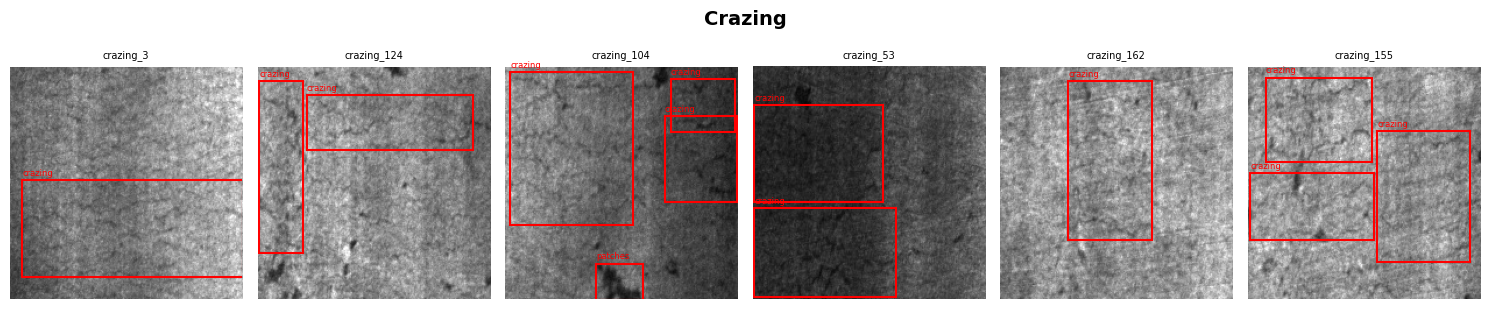

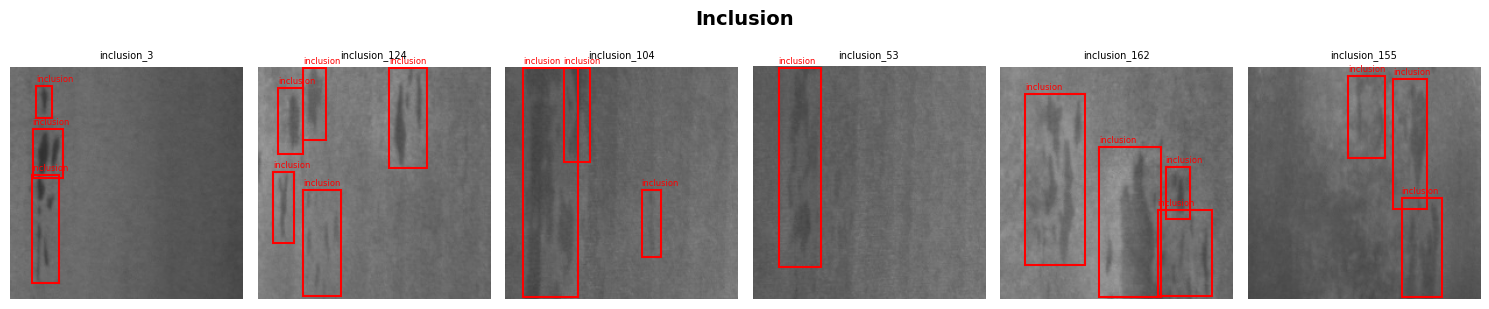

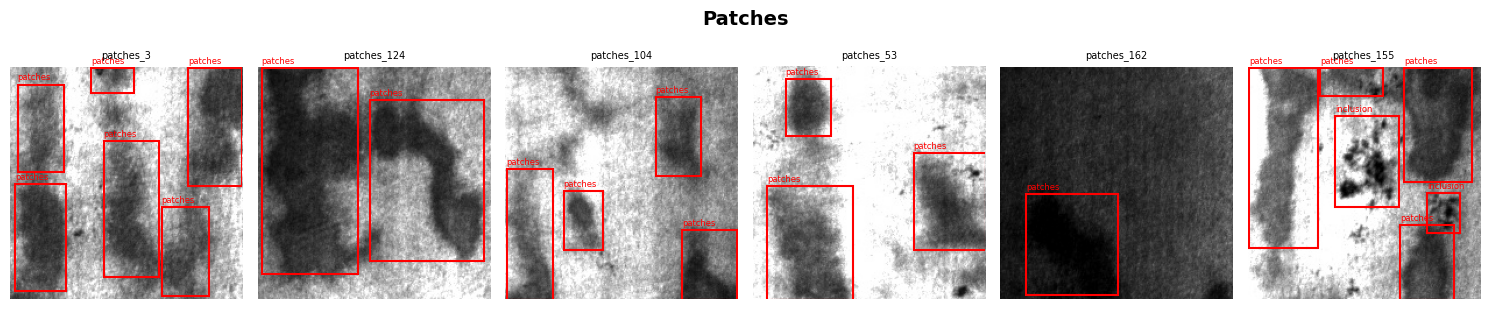

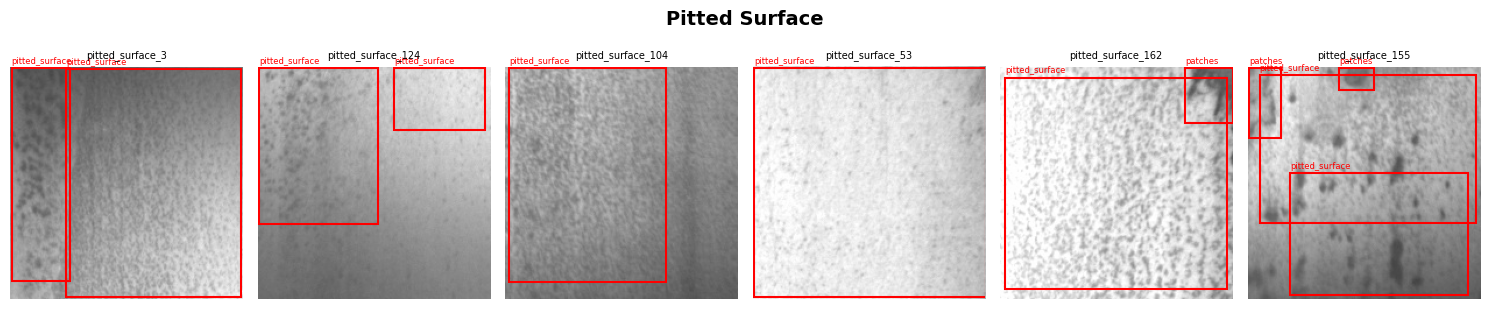

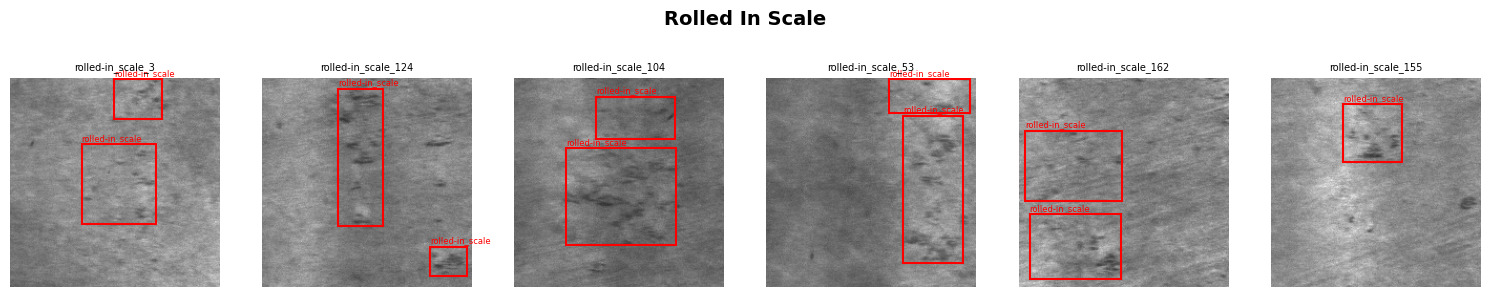

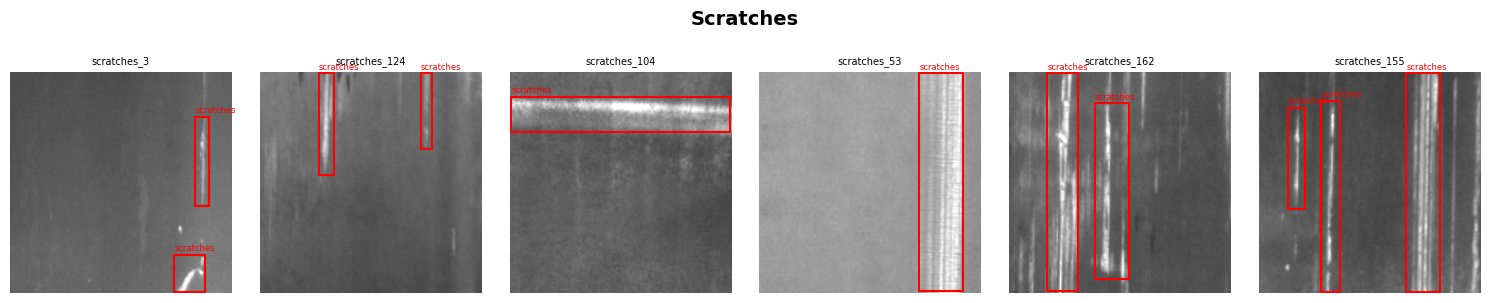

In [7]:
for cls in CLASSES:
    show_class_grid(cls, 6)

## Side-by-side comparison of selected candidates
Edit `CANDIDATES` below once you've narrowed down your choices.

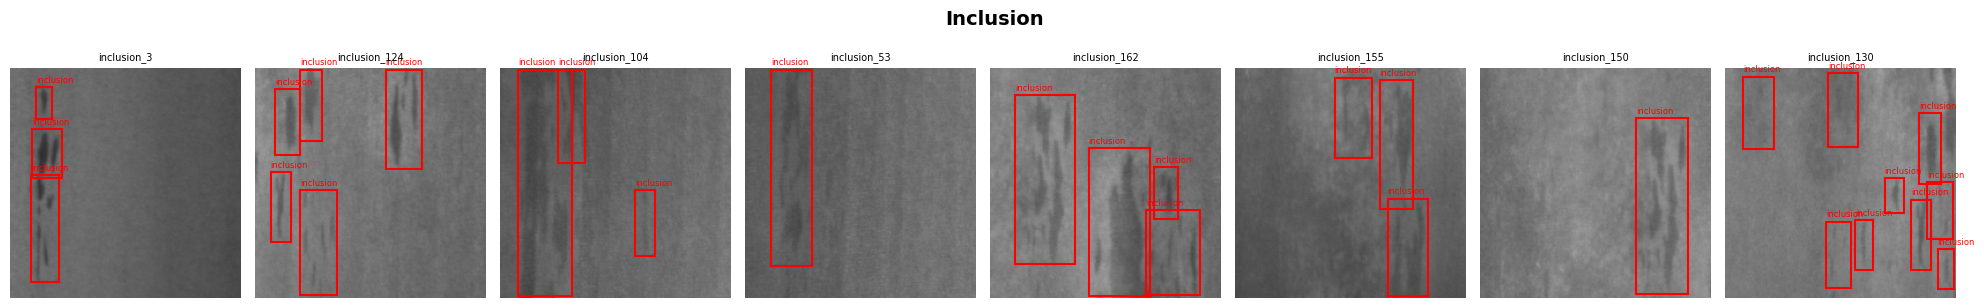

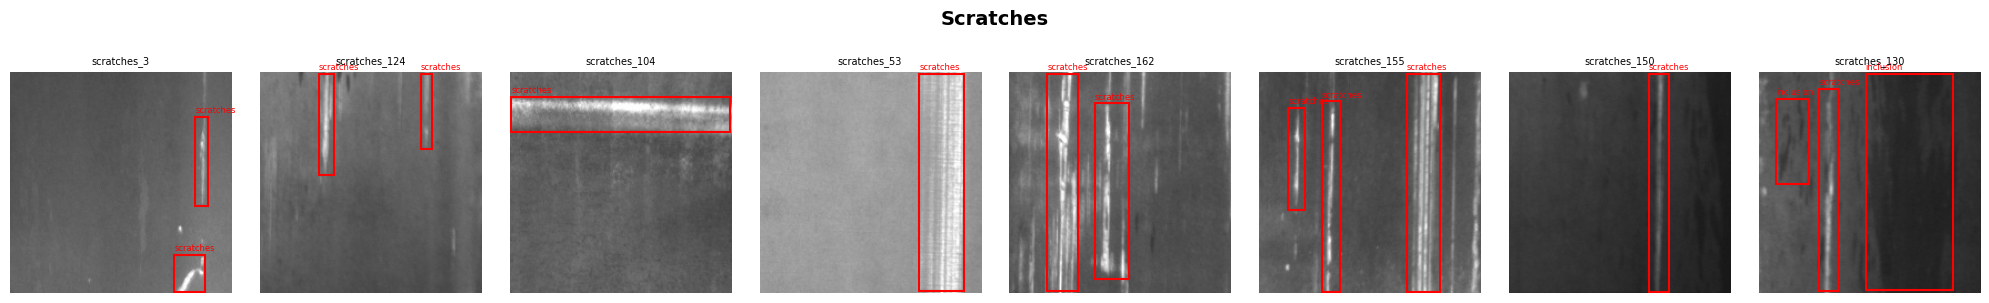

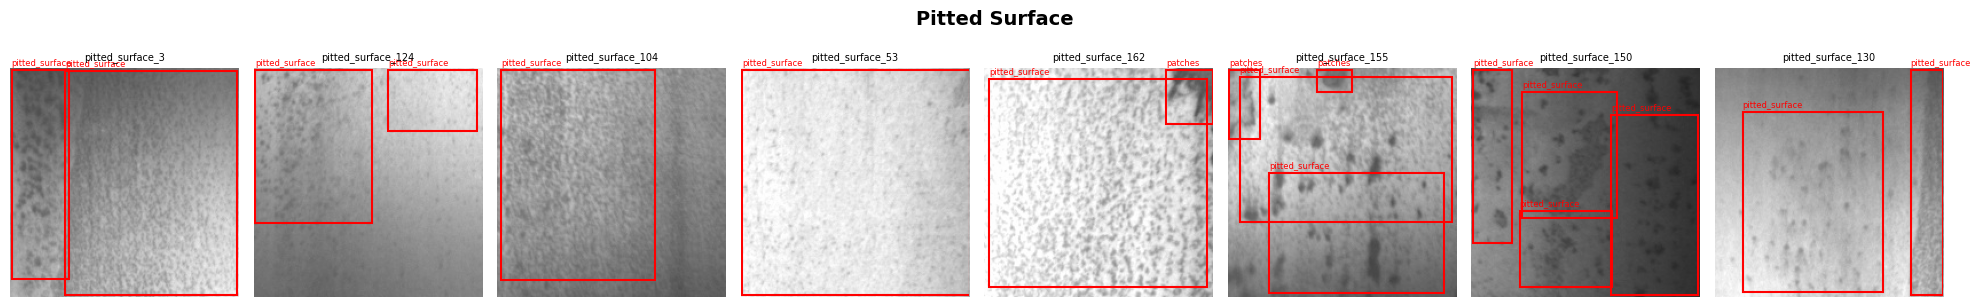

In [5]:
CANDIDATES = ["inclusion", "scratches", "pitted_surface"]  # edit me

for cls in CANDIDATES:
    show_class_grid(cls, n=8)